# Visualisasi Topic Modeling - pyLDAvis & BERTopic Cluster

Notebook ini membuat visualisasi interaktif dari hasil topic modeling:
1. **LDA** → pyLDAvis (visualisasi interaktif topik)
2. **BERTopic** → Topic Cluster (scatter plot 2D/3D)

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP

import os

os.makedirs('output', exist_ok=True)

## 2. Load Data & Sampling 50%

In [2]:
df = pd.read_csv('data/representasi.csv')
print(f"Dataset asli: {len(df)} baris")

df_sampled = df.sample(frac=0.5, random_state=42).reset_index(drop=True)
print(f"Dataset setelah sampling 50%: {len(df_sampled)} baris")

texts = [str(t).strip() for t in df_sampled['text_final'].tolist()]
texts = [t for t in texts if len(t) > 0]
print(f"Jumlah dokumen valid: {len(texts)}")
print(f"Tipe data contoh: {type(texts[0])}")

Dataset asli: 13574 baris
Dataset setelah sampling 50%: 6787 baris
Jumlah dokumen valid: 6787
Tipe data contoh: <class 'str'>


## 3. LDA → pyLDAvis

In [3]:
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=10000)
doc_term_matrix = vectorizer.fit_transform(texts)
print(f"Shape Document-Term Matrix: {doc_term_matrix.shape}")

Shape Document-Term Matrix: (6787, 4599)


In [4]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary

k_values = [5, 8, 10, 12, 15, 20]
lda_models = {}
lda_results = []

tokens_list = [t.split() for t in texts]
dictionary = Dictionary(tokens_list)
dictionary.filter_extremes(no_below=2, no_above=0.95)

for k in k_values:
    print(f"\nTraining LDA dengan k={k}...")
    
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='online',
        learning_offset=50.,
        max_iter=10,
        batch_size=128,
        evaluate_every=-1
    )
    lda.fit(doc_term_matrix)
    lda_models[k] = lda
    
    perplexity = lda.perplexity(doc_term_matrix)
    
    topic_words = []
    for topic_idx, topic in enumerate(lda.components_):
        top_words = [vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]]
        topic_words.append(top_words)
    
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokens_list,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    
    lda_results.append({'k': k, 'perplexity': perplexity, 'coherence': coherence})
    print(f"  Coherence: {coherence:.4f}, Perplexity: {perplexity:.2f}")

results_df = pd.DataFrame(lda_results)
best_k = results_df.loc[results_df['coherence'].idxmax(), 'k']
print(f"\nTopik optimal: k = {best_k}")
best_lda = lda_models[best_k]


Training LDA dengan k=5...
  Coherence: 0.5068, Perplexity: 764.99

Training LDA dengan k=8...
  Coherence: 0.5098, Perplexity: 799.22

Training LDA dengan k=10...
  Coherence: 0.4782, Perplexity: 828.40

Training LDA dengan k=12...
  Coherence: 0.4656, Perplexity: 851.37

Training LDA dengan k=15...
  Coherence: 0.4752, Perplexity: 876.96

Training LDA dengan k=20...
  Coherence: 0.4300, Perplexity: 909.35

Topik optimal: k = 8


In [5]:
doc_topic_dists = best_lda.transform(doc_term_matrix)
topic_term_dists = best_lda.components_
topic_term_dists = (topic_term_dists / topic_term_dists.sum(axis=1)[:, np.newaxis]).astype(np.float64)

doc_lengths = np.asarray(doc_term_matrix.sum(axis=1)).flatten()
vocab = vectorizer.get_feature_names_out()
term_frequency = np.asarray(doc_term_matrix.sum(axis=0)).flatten()

lda_vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=list(vocab),
    term_frequency=term_frequency,
    mds='mmds',
    sort_topics=False
)

pyLDAvis.save_html(lda_vis_data, 'output/pyLDAvis_interactive.html')
pyLDAvis.display(lda_vis_data)

print("pyLDAvis disimpan ke: output/pyLDAvis_interactive.html")

pyLDAvis disimpan ke: output/pyLDAvis_interactive.html


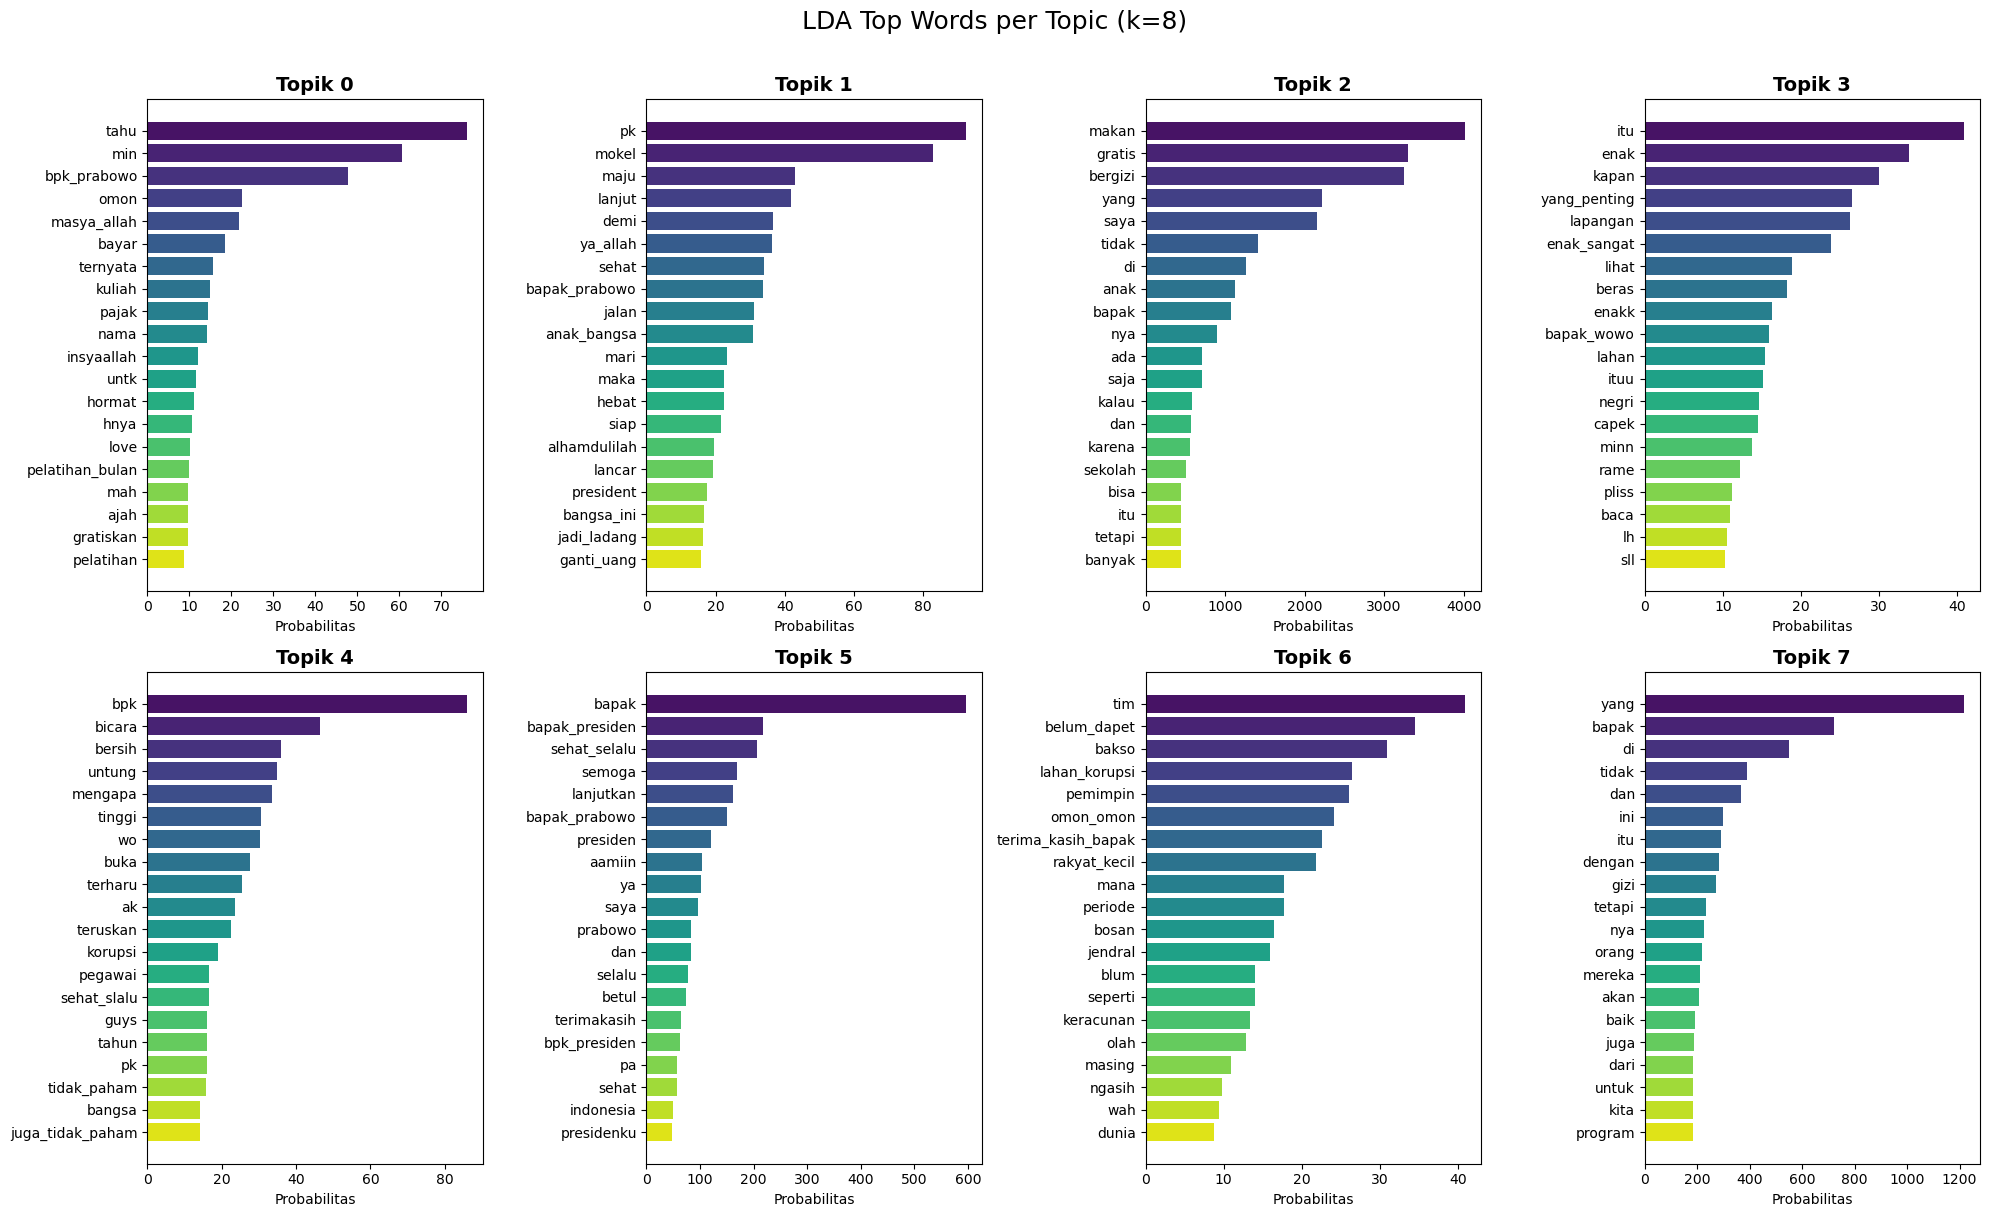

In [6]:
feature_names = vectorizer.get_feature_names_out()
n_top_words = 20

fig, axes = plt.subplots(2, (best_k+1)//2, figsize=(20, 12))
if best_k == 1:
    axes = [axes]
axes = axes.flatten()

for topic_idx in range(best_k):
    topic_words_idx = best_lda.components_[topic_idx].argsort()[:-n_top_words-1:-1]
    top_words = [feature_names[i] for i in topic_words_idx]
    top_probs = best_lda.components_[topic_idx][topic_words_idx]
    
    axes[topic_idx].barh(range(len(top_words)), top_probs, color=sns.color_palette('viridis', len(top_words)))
    axes[topic_idx].set_yticks(range(len(top_words)))
    axes[topic_idx].set_yticklabels(top_words, fontsize=10)
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_title(f'Topik {topic_idx}', fontsize=14, fontweight='bold')
    axes[topic_idx].set_xlabel('Probabilitas')

for j in range(topic_idx + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'LDA Top Words per Topic (k={best_k})', fontsize=18, y=1.01)
plt.tight_layout()
plt.savefig('output/lda_pyldavis_top_words.png', dpi=300, bbox_inches='tight')
plt.show()

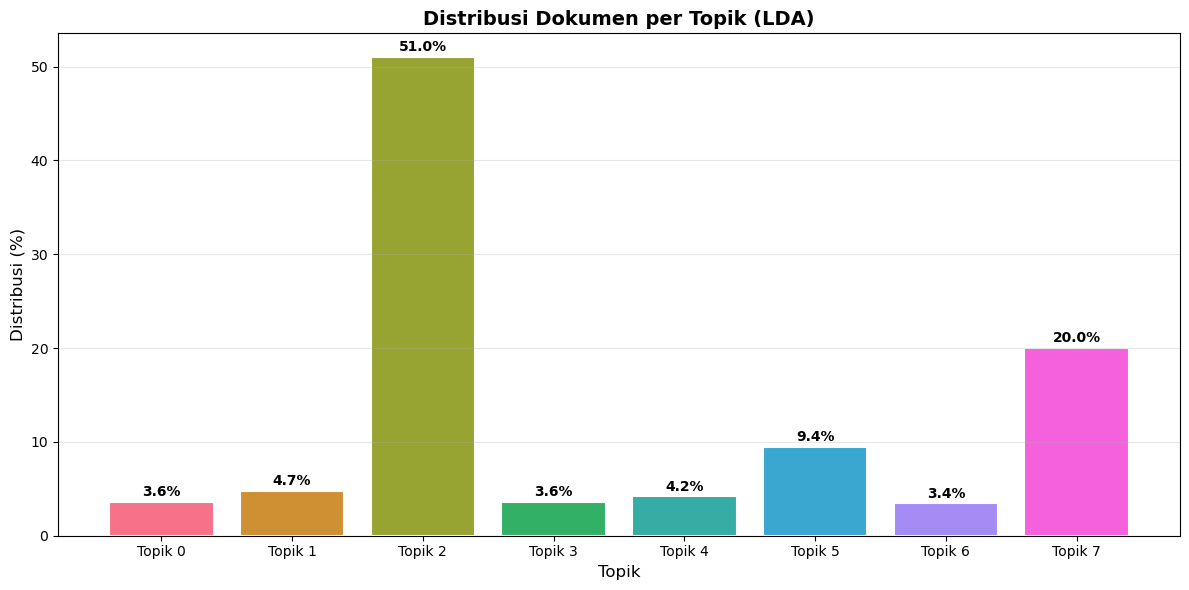

In [7]:
doc_topics = best_lda.transform(doc_term_matrix)
topic_distributions = doc_topics.sum(axis=0)
topic_distributions_pct = (topic_distributions / topic_distributions.sum()) * 100

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('husl', best_k)
bars = ax.bar(range(best_k), topic_distributions_pct, color=colors, edgecolor='white', linewidth=1.5)

for i, (bar, pct) in enumerate(zip(bars, topic_distributions_pct)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Topik', fontsize=12)
ax.set_ylabel('Distribusi (%)', fontsize=12)
ax.set_title('Distribusi Dokumen per Topik (LDA)', fontsize=14, fontweight='bold')
ax.set_xticks(range(best_k))
ax.set_xticklabels([f'Topik {i}' for i in range(best_k)])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/lda_topic_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

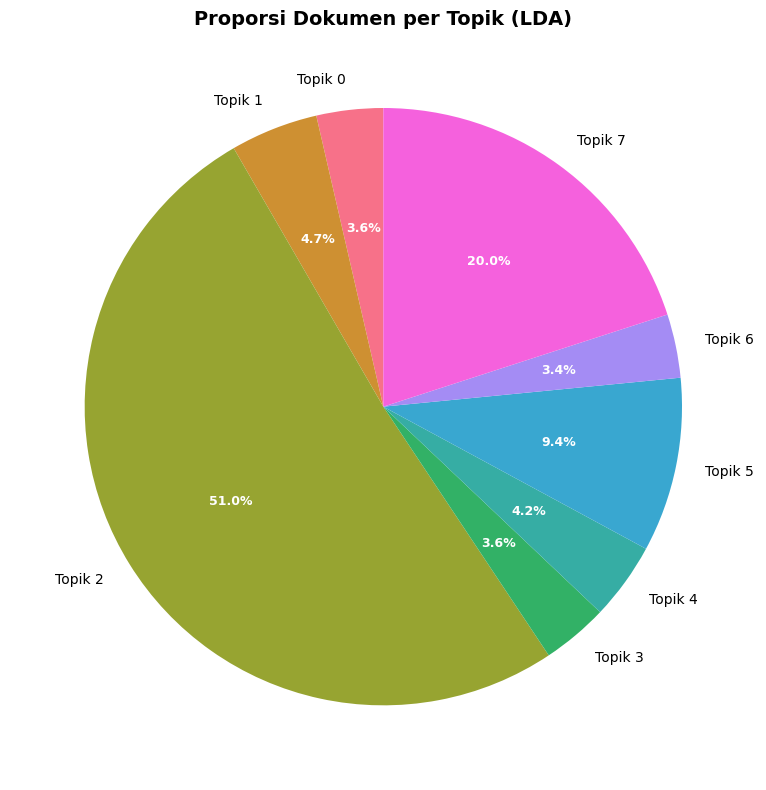

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    topic_distributions_pct,
    labels=[f'Topik {i}' for i in range(best_k)],
    autopct='%1.1f%%',
    colors=sns.color_palette('husl', best_k),
    startangle=90,
    textprops={'fontsize': 10}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

ax.set_title('Proporsi Dokumen per Topik (LDA)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/lda_topic_proportion_pie.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. BERTopic → Topic Cluster

In [9]:
print("Memuat model sentence transformer...")
embedding_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Model berhasil dimuat.")

Memuat model sentence transformer...
Model berhasil dimuat.


In [10]:
texts = [str(t).strip() for t in df_sampled['text_final'].tolist() if pd.notna(t)]
texts = [t for t in texts if len(t) > 3]
texts = list(map(str, texts))
print(f"Total dokumen valid: {len(texts)}")

if len(texts) == 0:
    raise ValueError("Dataset kosong! Cek kolom 'text_final'.")

print("Fitting BERTopic...")
topic_model = BERTopic(
    embedding_model=embedding_model,
    language='indonesian',
    nr_topics='auto',
    top_n_words=15,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)
n_real_topics = len([t for t in set(topics) if t != -1])
n_outliers = topics.count(-1)

print(f"Jumlah topik: {n_real_topics}")
print(f"Outlier: {n_outliers}")

2026-05-04 12:24:17,653 - BERTopic - Embedding - Transforming documents to embeddings.


Total dokumen valid: 6764
Fitting BERTopic...


Batches:   0%|          | 0/212 [00:00<?, ?it/s]

2026-05-04 12:25:04,988 - BERTopic - Embedding - Completed ✓
2026-05-04 12:25:04,989 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-04 12:25:35,738 - BERTopic - Dimensionality - Completed ✓
2026-05-04 12:25:35,740 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-04 12:25:38,386 - BERTopic - Cluster - Completed ✓
2026-05-04 12:25:38,387 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-04 12:25:38,565 - BERTopic - Representation - Completed ✓
2026-05-04 12:25:38,566 - BERTopic - Topic reduction - Reducing number of topics
2026-05-04 12:25:38,595 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-04 12:25:38,726 - BERTopic - Representation - Completed ✓
2026-05-04 12:25:38,729 - BERTopic - Topic reduction - Reduced number of topics from 94 to 41


Jumlah topik: 40
Outlier: 2568


In [11]:
embeddings = embedding_model.encode(texts, show_progress_bar=True)
print(f"Shape embeddings: {embeddings.shape}")

Batches:   0%|          | 0/212 [00:00<?, ?it/s]

Shape embeddings: (6764, 384)


In [12]:
umap_model = UMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_2d = umap_model.fit_transform(embeddings)
print(f"Shape setelah UMAP 2D: {embeddings_2d.shape}")

Shape setelah UMAP 2D: (6764, 2)


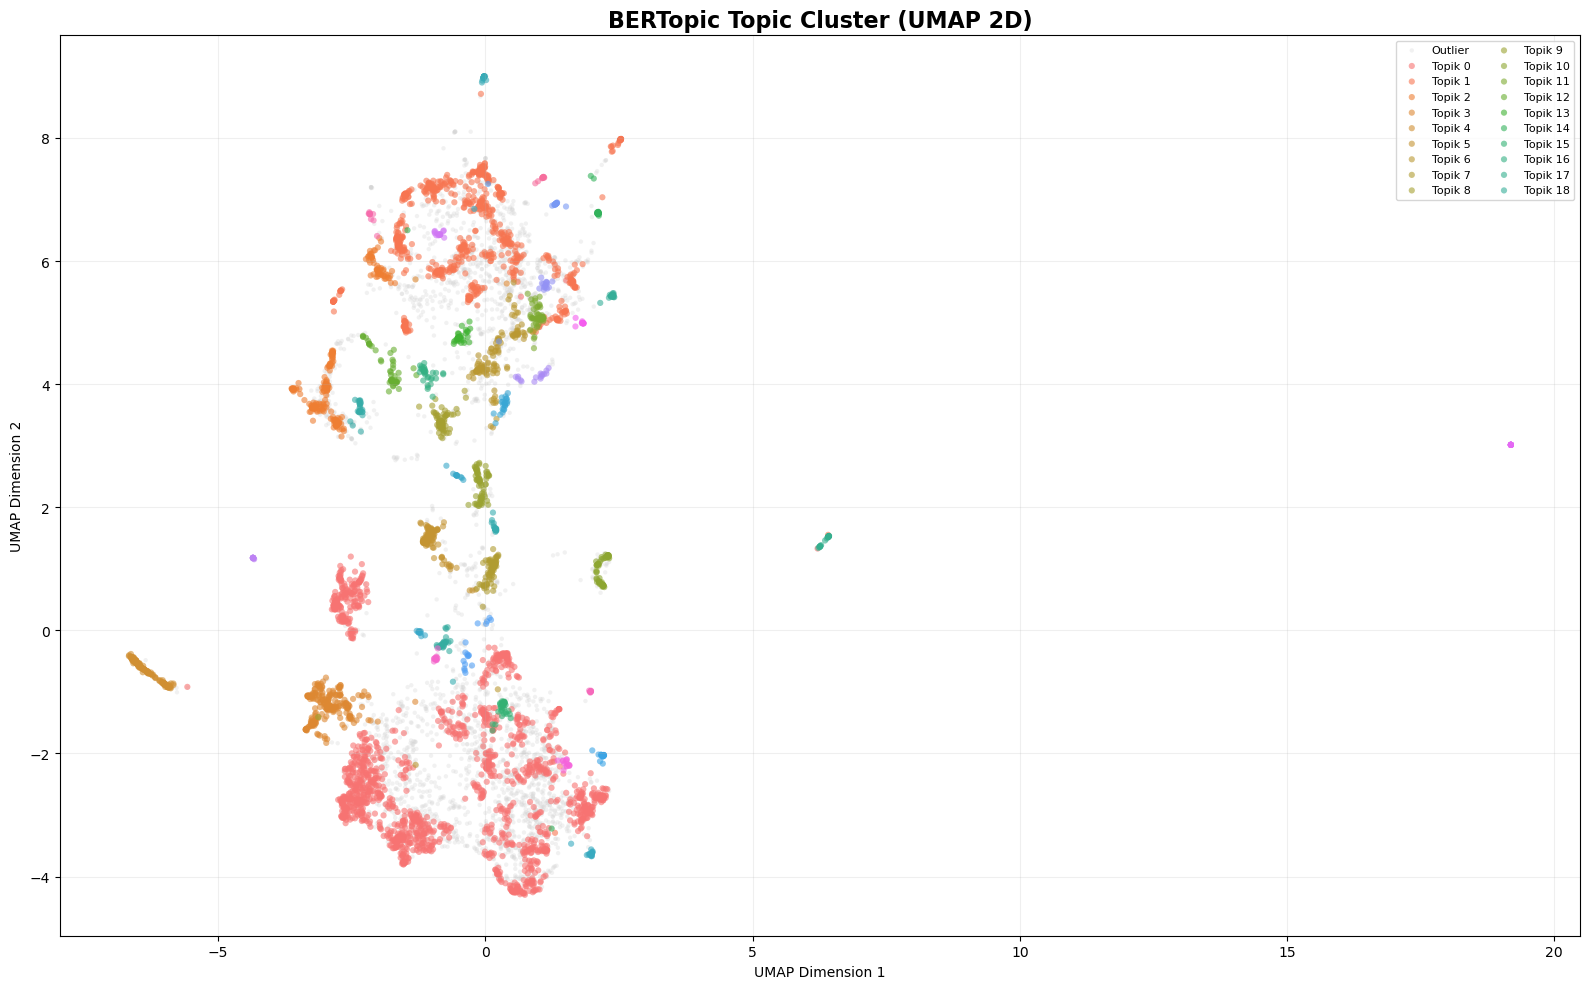

In [13]:
unique_topics = sorted(list(set(topics)))
n_colors = len(unique_topics)
palette = sns.color_palette('husl', n_colors)
color_map = {topic: palette[i] for i, topic in enumerate(unique_topics)}

fig, ax = plt.subplots(figsize=(16, 10))

for topic_id in unique_topics:
    mask = [t == topic_id for t in topics]
    x = embeddings_2d[mask, 0]
    y = embeddings_2d[mask, 1]
    
    if topic_id == -1:
        ax.scatter(x, y, c='lightgray', s=10, alpha=0.3, label='Outlier', edgecolors='none')
    else:
        label = f'Topik {topic_id}'
        ax.scatter(x, y, c=[color_map[topic_id]], s=20, alpha=0.6, label=label, edgecolors='none')

ax.set_title('BERTopic Topic Cluster (UMAP 2D)', fontsize=16, fontweight='bold')
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')

handles, labels = ax.get_legend_handles_labels()
if len(labels) > 20:
    ax.legend(handles[:20], labels[:20], loc='best', fontsize=8, ncol=2)
else:
    ax.legend(loc='best', fontsize=9, ncol=2)

ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('output/bertopic_cluster_2d.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
import plotly.express as px
import plotly.graph_objects as go

topic_labels = [f'Topik {t}' if t != -1 else 'Outlier' for t in topics]

fig = px.scatter(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    color=topic_labels,
    title='BERTopic Topic Cluster (UMAP 2D - Interaktif)',
    labels={'x': 'UMAP Dimension 1', 'y': 'UMAP Dimension 2'},
    color_discrete_sequence=px.colors.qualitative.Set3,
    opacity=0.7,
    width=1000,
    height=700
)

fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='DarkSlateGrey')))
fig.update_layout(legend=dict(itemsizing='constant'))
fig.write_html('output/bertopic_cluster_2d_interactive.html')
fig.show()

In [15]:
umap_3d = UMAP(
    n_neighbors=15,
    n_components=3,
    min_dist=0.0,
    metric='cosine',
    random_state=42
)

embeddings_3d = umap_3d.fit_transform(embeddings)

fig = px.scatter_3d(
    x=embeddings_3d[:, 0],
    y=embeddings_3d[:, 1],
    z=embeddings_3d[:, 2],
    color=topic_labels,
    title='BERTopic Topic Cluster (UMAP 3D - Interaktif)',
    labels={'x': 'UMAP Dim 1', 'y': 'UMAP Dim 2', 'z': 'UMAP Dim 3'},
    color_discrete_sequence=px.colors.qualitative.Set3,
    opacity=0.7,
    width=1000,
    height=800
)

fig.update_traces(marker=dict(size=3))
fig.write_html('output/bertopic_cluster_3d_interactive.html')
fig.show()

In [16]:
fig = topic_model.visualize_topics()
fig.write_html('output/bertopic_cluster_visualize.html')
fig.show()

In [17]:
fig = topic_model.visualize_hierarchy()
fig.write_html('output/bertopic_cluster_hierarchy.html')
fig.show()

In [18]:
fig = topic_model.visualize_heatmap()
fig.write_html('output/bertopic_cluster_heatmap.html')
fig.show()

In [19]:
fig = topic_model.visualize_barchart()
fig.write_html('output/bertopic_cluster_barchart.html')
fig.show()

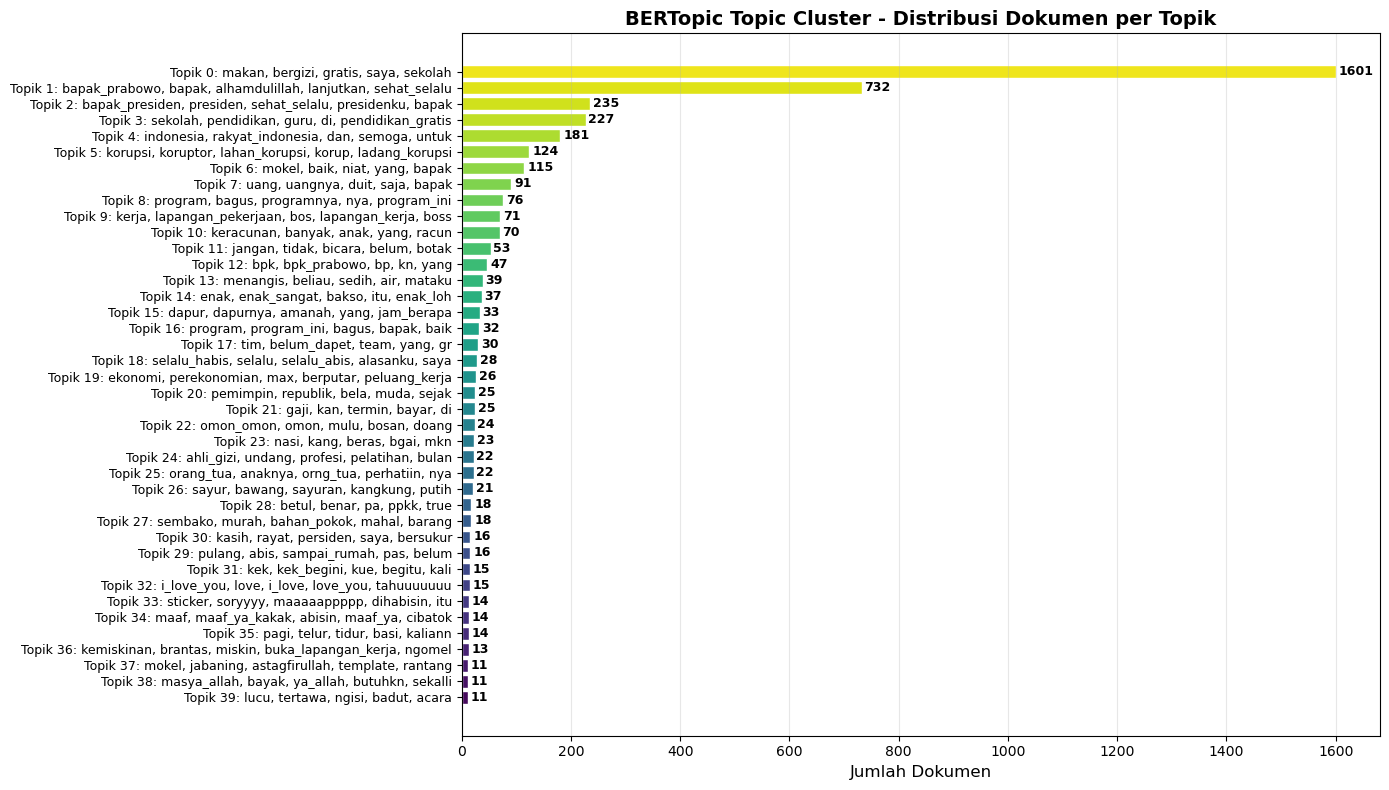

In [20]:
topic_info = topic_model.get_topic_info()

fig, ax = plt.subplots(figsize=(14, 8))

real_topics_info = topic_info[topic_info['Topic'] != -1].sort_values('Count', ascending=True)

colors = sns.color_palette('viridis', len(real_topics_info))
bars = ax.barh(
    range(len(real_topics_info)),
    real_topics_info['Count'].values,
    color=colors,
    edgecolor='white',
    linewidth=1
)

for i, (bar, count, topic_id) in enumerate(zip(
    bars,
    real_topics_info['Count'].values,
    real_topics_info['Topic'].values
)):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2.,
            f'{int(count)}', va='center', fontsize=9, fontweight='bold')

topic_labels_y = []
for _, row in real_topics_info.iterrows():
    topic_words = ', '.join([w for w, _ in topic_model.get_topic(row['Topic'])[:5]])
    topic_labels_y.append(f"Topik {row['Topic']}: {topic_words}")

ax.set_yticks(range(len(real_topics_info)))
ax.set_yticklabels(topic_labels_y, fontsize=9)
ax.set_xlabel('Jumlah Dokumen', fontsize=12)
ax.set_title('BERTopic Topic Cluster - Distribusi Dokumen per Topik', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('output/bertopic_cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

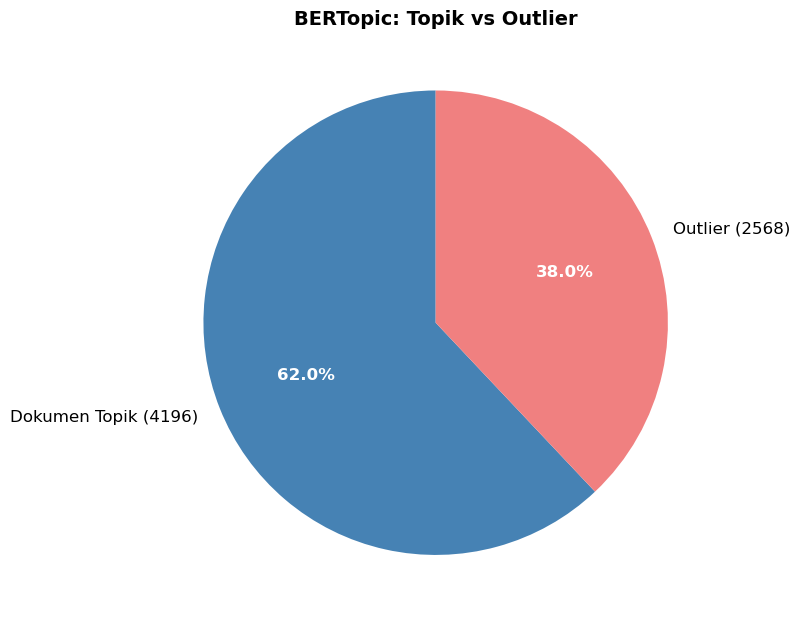

In [21]:
outlier_count = topic_info[topic_info['Topic'] == -1]['Count'].values[0] if -1 in topic_info['Topic'].values else 0
real_total = topic_info[topic_info['Topic'] != -1]['Count'].sum()

sizes = [real_total, outlier_count]
labels_plot = [f'Dokumen Topik ({real_total})', f'Outlier ({outlier_count})']
colors_plot = ['steelblue', 'lightcoral']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels_plot,
    autopct='%1.1f%%',
    colors=colors_plot,
    startangle=90,
    textprops={'fontsize': 12}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('BERTopic: Topik vs Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/bertopic_outlier_pie.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Ringkasan Visualisasi

In [22]:
print("\n" + "="*60)
print("RINGKASAN VISUALISASI")
print("="*60)

print("\n📊 LDA → pyLDAvis:")
print(f"   - pyLDAvis interaktif: output/pyLDAvis_interactive.html")
print(f"   - Top words per topik: output/lda_pyldavis_top_words.png")
print(f"   - Distribusi topik (bar): output/lda_topic_distribution_pie.png")
print(f"   - Proporsi topik (pie): output/lda_topic_proportion_pie.png")

print("\n🔵 BERTopic → Topic Cluster:")
print(f"   - Cluster 2D (static): output/bertopic_cluster_2d.png")
print(f"   - Cluster 2D (interaktif): output/bertopic_cluster_2d_interactive.html")
print(f"   - Cluster 3D (interaktif): output/bertopic_cluster_3d_interactive.html")
print(f"   - Visualize topics: output/bertopic_cluster_visualize.html")
print(f"   - Hierarchical: output/bertopic_cluster_hierarchy.html")
print(f"   - Heatmap: output/bertopic_cluster_heatmap.html")
print(f"   - Bar chart: output/bertopic_cluster_barchart.html")
print(f"   - Distribusi topik: output/bertopic_cluster_distribution.png")
print(f"   - Outlier pie: output/bertopic_outlier_pie.png")

print(f"\n📈 Statistik:")
print(f"   - LDA optimal k: {best_k}")
print(f"   - BERTopic topik: {n_real_topics}")
print(f"   - BERTopic outlier: {n_outliers}")
print("="*60)


RINGKASAN VISUALISASI

📊 LDA → pyLDAvis:
   - pyLDAvis interaktif: output/pyLDAvis_interactive.html
   - Top words per topik: output/lda_pyldavis_top_words.png
   - Distribusi topik (bar): output/lda_topic_distribution_pie.png
   - Proporsi topik (pie): output/lda_topic_proportion_pie.png

🔵 BERTopic → Topic Cluster:
   - Cluster 2D (static): output/bertopic_cluster_2d.png
   - Cluster 2D (interaktif): output/bertopic_cluster_2d_interactive.html
   - Cluster 3D (interaktif): output/bertopic_cluster_3d_interactive.html
   - Visualize topics: output/bertopic_cluster_visualize.html
   - Hierarchical: output/bertopic_cluster_hierarchy.html
   - Heatmap: output/bertopic_cluster_heatmap.html
   - Bar chart: output/bertopic_cluster_barchart.html
   - Distribusi topik: output/bertopic_cluster_distribution.png
   - Outlier pie: output/bertopic_outlier_pie.png

📈 Statistik:
   - LDA optimal k: 8
   - BERTopic topik: 40
   - BERTopic outlier: 2568
